# Análisis de perfil y desempeño 01/06/2026

# Librerías

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
import scipy.stats as stats
import numpy as np
import plotly.graph_objs as go
import seaborn as sns
from scipy.stats import spearmanr 

# Funciones

In [34]:
def distr_hist(df: pd.DataFrame, column: str, bars: int) -> None:
    """
    Muestra un histograma para una columna del DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a visualizar.
    bars : int
        Número de barras del histograma.
    """
    plt.hist(df[column], bins=bars)
    plt.title(f'Distribución de la variable {column}')
    plt.show()

In [35]:
def distr_value(df: pd.DataFrame, column: str) -> None:
    """
    Muestra la distribución porcentual y los valores únicos de una columna.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a analizar.
    """
    value_count = df[column].value_counts(normalize=True)*100
    print(f'Value counts: {value_count}')
    val_unique = df[column].unique()
    print(f'----\nValores únicos:{val_unique}')
    
    print('----\nGráfico distribución valores únicos:')
    (df[column]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind='bar'))

    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Hit_target')
    plt.title('Distribución de Hit_target')
    plt.show()                  

In [36]:
def distr_boxplot(df: pd.DataFrame, column: str) -> None:
    """
    Muestra un boxplot para una columna del DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a visualizar.
    """
    plt.boxplot(df[column])
    plt.title(f'Boxplot de la variable {column}')
    plt.show()

In [37]:
def outliers_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Devuelve las filas con valores atípicos en una columna usando el método IQR.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna numérica a analizar.
    """
    col = df[column]

    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    limit_inferior = Q1 - 1.5 * IQR
    limit_superior = Q3 + 1.5 * IQR

    outliers = df[(col < limit_inferior) | (col > limit_superior)]
    
    return outliers

# Documento

In [38]:
df_RRHH = pd.read_csv('../../Data/clean/clean_data_01062026.csv')
df_RRHH

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,...,2,0,0,1,65,172,22,22.0,112,2026-05-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-06-01
840,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-06-01
841,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-06-01
842,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-06-01


In [39]:
df_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       844 non-null    int64  
 1   Reason_absence           802 non-null    float64
 2   Reason_absence_name      802 non-null    object 
 3   Month_absence            841 non-null    float64
 4   Month_absence_name       841 non-null    object 
 5   Day_week                 844 non-null    int64  
 6   Day_week_name            844 non-null    object 
 7   Seasons                  844 non-null    int64  
 8   Seasons_name             844 non-null    object 
 9   Transportation_expense   844 non-null    int64  
 10  Distance_Residence_Work  844 non-null    int64  
 11  Service_time             844 non-null    int64  
 12  Age                      844 non-null    int64  
 13  Work_load_Average_day    844 non-null    float64
 14  Hit_target               8

In [40]:
df_RRHH.shape

(844, 28)

In [41]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,844.0,26.125592,26.389515,1.000,10.000,20.000,33.000,136.000
Reason_absence,802.0,20.314214,7.176987,1.000,13.000,23.000,27.000,28.000
Month_absence,841.0,6.527943,3.400209,1.000,4.000,7.000,9.000,12.000
Day_week,844.0,3.928910,1.416617,2.000,3.000,4.000,5.000,6.000
Seasons,844.0,2.523697,1.095946,1.000,2.000,3.000,3.000,4.000
Transportation_expense,844.0,220.477488,67.456296,118.000,179.000,225.000,260.000,388.000
Distance_Residence_Work,844.0,29.422986,14.748504,5.000,16.000,26.000,49.000,52.000
Service_time,844.0,12.582938,4.425366,1.000,9.000,12.500,16.000,29.000
Age,844.0,36.453791,6.552751,27.000,31.000,37.000,40.000,58.000
Work_load_Average_day,844.0,271.957630,39.054208,205.917,244.387,264.604,294.217,378.884


In [42]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='object')

Listas de columnas numéricas y categóricas separadas de todo el dataset (con 'ID')

In [43]:
num = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target','Pet', 'Son',
       'Weight', 'Height', 'Absenteeism_hours', 'BMI_calculated']

cat = ['ID','Reason_absence', 'Month_absence', 'Day_week',
       'Seasons', 'Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

## Tamaño de muestra

In [44]:
df_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       844 non-null    int64  
 1   Reason_absence           802 non-null    float64
 2   Reason_absence_name      802 non-null    object 
 3   Month_absence            841 non-null    float64
 4   Month_absence_name       841 non-null    object 
 5   Day_week                 844 non-null    int64  
 6   Day_week_name            844 non-null    object 
 7   Seasons                  844 non-null    int64  
 8   Seasons_name             844 non-null    object 
 9   Transportation_expense   844 non-null    int64  
 10  Distance_Residence_Work  844 non-null    int64  
 11  Service_time             844 non-null    int64  
 12  Age                      844 non-null    int64  
 13  Work_load_Average_day    844 non-null    float64
 14  Hit_target               8

In [45]:
# Función para calcular la moda de variables categóricas/temporales
def moda(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

df_emp = df_RRHH.groupby('ID').agg(
    # Variable dependiente agregada a nivel empleado
    Hit_target_median=('Hit_target', 'median'),
    Hit_target_mean=('Hit_target', 'mean'),

    # Número de solicitudes / registros de ausencia por empleado
    num_absences=('ID', 'size'),

    # Variables numéricas del empleado
    Age=('Age', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),

    # Variables que pueden variar por registro
    Absenteeism_hours_total=('Absenteeism_hours', 'sum'),
    Absenteeism_hours_median=('Absenteeism_hours', 'median'),
    # Work_load_Average_day_median=('Work_load_Average_day', 'median'),

    # Variables categóricas/dummy del empleado
    Disciplinary_failure=('Disciplinary_failure', 'first'),
    Education=('Education', 'first'),
    Son=('Son', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    Pet=('Pet', 'first'),

    # Variables temporales: valor más frecuente por empleado
    Month_absence_mode=('Month_absence', moda),
    Seasons_mode=('Seasons', moda)
).reset_index()

In [46]:
variables_grupo = [
    'Disciplinary_failure',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet'
]

for var in variables_grupo:
    #print(f"\n{var}")
    print(df_emp[var].value_counts(dropna=False))
    print(df_emp[var].value_counts(normalize=True, dropna=False) * 100)

Disciplinary_failure
0    135
1      1
Name: count, dtype: int64
Disciplinary_failure
0    99.264706
1     0.735294
Name: proportion, dtype: float64
Education
1    114
3     12
2      9
4      1
Name: count, dtype: int64
Education
1    83.823529
3     8.823529
2     6.617647
4     0.735294
Name: proportion, dtype: float64
Son
0    59
1    41
2    28
3     5
4     3
Name: count, dtype: int64
Son
0    43.382353
1    30.147059
2    20.588235
3     3.676471
4     2.205882
Name: proportion, dtype: float64
Social_drinker
1    71
0    65
Name: count, dtype: int64
Social_drinker
1    52.205882
0    47.794118
Name: proportion, dtype: float64
Social_smoker
0    122
1     14
Name: count, dtype: int64
Social_smoker
0    89.705882
1    10.294118
Name: proportion, dtype: float64
Pet
0    83
1    24
2    21
4     5
8     2
5     1
Name: count, dtype: int64
Pet
0    61.029412
1    17.647059
2    15.441176
4     3.676471
8     1.470588
5     0.735294
Name: proportion, dtype: float64


## df individuo (df_RRHH_ind_grouped)
**df_RRHH_ind_grouped** con:
- Variables sociodemográficas de cada individuo agrupadas
- Mediana de work_load_average_day y de hit target
- Conteo del número de ausencias (count de las solicitudes que tienen más de 0 horas)
- Sma de horas de absentismo.

In [47]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='object')

In [48]:
df_RRHH_ind = df_RRHH[[
        'ID', 'Transportation_expense', 'Distance_Residence_Work',
        'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
        'Disciplinary_failure', 'Education', 'Education_name', 'Son',
        'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
        'BMI_calculated', 'Absenteeism_hours',
        ]].copy()

In [49]:
df_RRHH_ind.shape

(844, 18)

In [50]:
df_RRHH_ind.sample(5)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated,Absenteeism_hours
138,10,361,52,3,28,275.312,98,0,1,Secundaria,1,1,0,4,80,172,27.0,8
180,23,378,49,11,36,244.387,98,0,1,Secundaria,2,0,1,4,65,174,21.5,8
720,18,330,16,4,28,284.031,97,1,2,Grado,0,0,0,0,84,182,25.4,0
552,3,179,51,18,38,264.249,97,0,1,Secundaria,0,1,0,0,89,170,30.8,2
541,28,225,26,9,28,268.519,93,0,1,Secundaria,1,0,0,2,69,169,24.2,2


In [51]:
cols_first = [
    'Transportation_expense', 'Distance_Residence_Work',
    'Service_time', 'Age',
    'Disciplinary_failure', 'Education', 'Education_name', 'Son',
    'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
    'BMI_calculated'
]

df_RRHH_ind_grouped = (
    df_RRHH_ind
    .groupby('ID')
    .agg(
        **{col: (col, 'first') for col in cols_first},
        Work_load_Average_day=('Work_load_Average_day', 'median'),
        Hit_target=('Hit_target', 'median'),
        Absenteeism_hours=('Absenteeism_hours', 'sum'),
        Absence_count=('Absenteeism_hours', lambda x: (x > 0).sum())
    )
    .reset_index()
)

df_RRHH_ind_grouped[['Work_load_Average_day', 'Hit_target']] = (
    df_RRHH_ind_grouped[['Work_load_Average_day', 'Hit_target']]
    .round(3)
)

In [52]:
df_RRHH_ind_grouped

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated,Work_load_Average_day,Hit_target,Absenteeism_hours,Absence_count
0,1,235,11,14,37,0,3,Posgrado,1,0,0,1,88,172,29.7,249.797,95.0,121,22
1,2,235,29,12,48,0,1,Secundaria,1,0,1,5,88,163,33.1,218.104,92.0,25,4
2,3,179,51,18,38,0,1,Secundaria,0,1,0,0,89,170,30.8,253.465,96.0,482,112
3,4,118,14,13,40,0,1,Secundaria,1,1,0,8,98,170,33.9,271.219,95.0,0,0
4,5,235,20,13,43,0,1,Secundaria,1,1,0,0,106,167,38.0,265.017,93.0,104,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,132,118,13,18,50,0,1,Secundaria,1,1,0,0,98,178,30.9,244.387,98.0,3,1
132,133,118,10,10,37,0,1,Secundaria,0,0,0,0,83,172,28.1,241.476,92.0,3,1
133,134,118,10,10,37,0,1,Secundaria,0,0,0,0,83,172,28.1,268.519,93.0,8,1
134,135,225,26,9,28,0,1,Secundaria,1,0,0,2,69,169,24.2,378.884,92.0,8,1


In [53]:
df_RRHH_ind_grouped.columns

Index(['ID', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Disciplinary_failure', 'Education',
       'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
       'Weight', 'Height', 'BMI_calculated', 'Work_load_Average_day',
       'Hit_target', 'Absenteeism_hours', 'Absence_count'],
      dtype='object')

Listas de columnas numéricas y categóricas separadas para el estudio de individuo (_ID)

In [54]:
num_ID = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Pet', 'Son', 'Weight', 'Height', 'BMI_calculated','Work_load_Average_day',
       'Hit_target', 'Absenteeism_hours', 'Absence_count']

cat_ID = ['ID','Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

## df ausencias sin variables sociodemográficas (df_RRHH_abs)
**df_RRHH_abs**  
Variables asociadas directamente con la solicitud de ausencia

In [55]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='object')

In [56]:
col_absence = [
    'ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
    'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
    'Seasons_name', 'Work_load_Average_day', 'Hit_target', 'Absenteeism_hours'
]

In [57]:
df_RRHH_abs = df_RRHH[col_absence].copy()

df_RRHH_abs

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Work_load_Average_day,Hit_target,Absenteeism_hours
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,284.031,97,120
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,239.409,98,120
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,264.604,93,120
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,230.290,92,112
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,222.196,99,112
...,...,...,...,...,...,...,...,...,...,...,...,...
839,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,284.031,97,120
840,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,239.409,98,120
841,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,264.604,93,120
842,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,230.290,92,112


# Pregunta de negocio

**Analista de Perfil i Desempeño Professional:**  
- Quines característiques dels empleats estan associades amb un millor acompliment laboral
- com podem utilitzar aquesta informació per dissenyar estratègies de selecció, capacitació i retenció més efectives?

## Análisis descriptivo

### Distribución variable hit target (histograma y boxplot [outliers])

In [58]:
distr_hist(df_RRHH_ind_grouped,'Hit_target',4) -que es esto?

Object `esto` not found.


Value counts: Hit_target
93.0     15.441176
95.0     14.705882
99.0     13.235294
96.0     10.294118
91.0      8.823529
92.0      8.088235
97.0      8.088235
98.0      5.882353
94.0      5.882353
81.0      2.941176
88.0      1.470588
96.5      1.470588
93.5      0.735294
97.5      0.735294
94.5      0.735294
100.0     0.735294
87.0      0.735294
Name: proportion, dtype: float64
----
Valores únicos:[ 95.   92.   96.   93.   94.5  88.   96.5  93.5  91.   97.5  98.   94.
  97.   99.  100.   81.   87. ]
----
Gráfico distribución valores únicos:


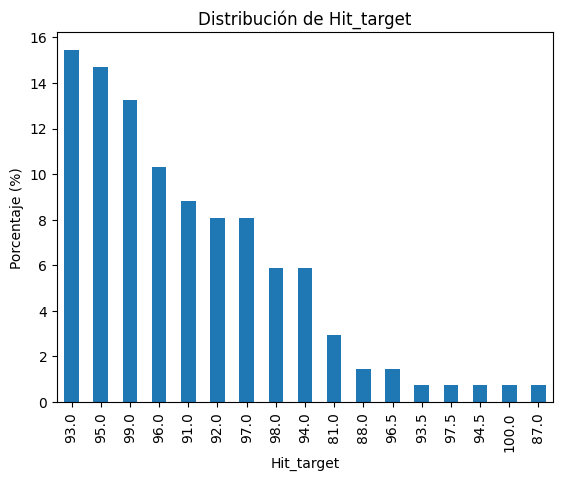

In [59]:
distr_value(df_RRHH_ind_grouped,'Hit_target')

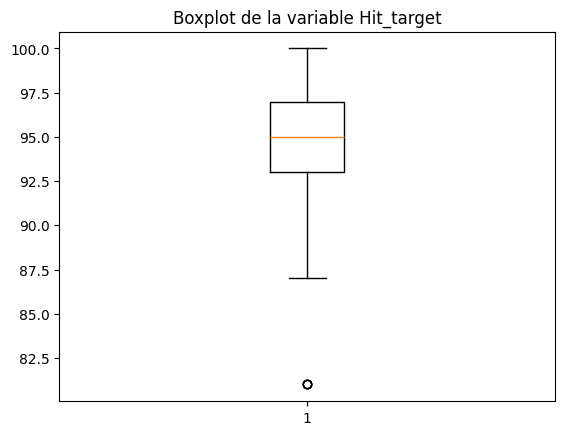

In [60]:
distr_boxplot(df_RRHH_ind_grouped,'Hit_target')

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
El valor **outlier es 81** (hay 23 registros), que es el mínimo, el siguiente valor es 88.

In [61]:
outliers_hit_target_all = outliers_column(df_RRHH,'Hit_target')
outliers_hit_target_all

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
20,15,7.0,Ojo y anexos,3.0,Marzo,2,Lunes,2,Primavera,291,...,1,1,0,1,73,171,25,25.0,40,2026-05-25
25,24,9.0,Sistema circulatorio,3.0,Marzo,4,Miércoles,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,32,2026-05-25
36,11,19.0,"Lesiones, intoxicaciones y consecuencias externas",3.0,Marzo,4,Miércoles,1,Invierno,289,...,2,1,0,1,90,172,30,30.4,24,2026-05-25
52,24,9.0,Sistema circulatorio,3.0,Marzo,2,Lunes,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,16,2026-05-25
148,3,11.0,Sistema digestivo,3.0,Marzo,2,Lunes,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
149,3,13.0,Sistema musculoesquelético,3.0,Marzo,4,Miércoles,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
150,5,26.0,Ausencia injustificada,3.0,Marzo,4,Miércoles,2,Primavera,235,...,1,1,0,0,106,167,38,38.0,8,2026-05-25
151,3,13.0,Sistema musculoesquelético,3.0,Marzo,2,Lunes,2,Primavera,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
301,15,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,291,...,1,1,0,1,73,171,25,25.0,4,2026-05-25
302,20,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,260,...,4,1,0,0,65,168,23,23.0,4,2026-05-25


### Para cada uno de los grupos de las otras variables

In [62]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='object')

analisis exploratorio distribución por individuo sin agrupar

## Correlacion Spearman

In [ ]:
# 1. Recuperar las variables numéricas definidas en el estudio de individuo
# Basado en la lista 'num_ID' de la fuente [4]
num_ID = [
    'Transportation_expense', 'Distance_Residence_Work', 'Service_time', 
    'Age', 'Pet', 'Son', 'Weight', 'Height', 'BMI_calculated',
    'Work_load_Average_day', 'Hit_target', 'Absenteeism_hours', 'Absence_count'
]

# 2. Calcular la matriz de correlación de Spearman
# Se utiliza Spearman porque Hit_target no es normal [2]
spearman_corr = df_RRHH_ind_grouped[num_ID].corr(method='spearman')


# 4. Extracción específica de asociaciones con Hit_target (Desempeño)
target_corr = spearman_corr['Hit_target'].sort_values(ascending=False)
print("Asociaciones con el Desempeño (Hit_target):")
print(target_corr)

Asociaciones con el Desempeño (Hit_target):
Hit_target                 1.000000
Height                     0.104287
Absence_count              0.049381
Absenteeism_hours          0.015056
Distance_Residence_Work   -0.001216
Son                       -0.031321
Service_time              -0.067977
Pet                       -0.077616
Age                       -0.080973
Work_load_Average_day     -0.103270
Transportation_expense    -0.109586
Weight                    -0.139090
BMI_calculated            -0.195817
Name: Hit_target, dtype: float64

Validación Service_time -> Coef: -0.068, P-value: 0.432


In [74]:
# 1. Definimos las variables numéricas del perfil (excluyendo ID y el propio Hit_target)
# Basado en tu lista num_ID de las fuentes
variables_analisis = [
    'BMI_calculated', 'Weight', 'Transportation_expense', 
    'Work_load_Average_day', 'Age', 'Pet', 'Service_time', 
    'Son', 'Height', 'Distance_Residence_Work', 
    'Absence_count', 'Absenteeism_hours'
]

# 2. Iteramos para calcular Coeficiente y P-Value
resultados_stats = []

for var in variables_analisis:
    # Aseguramos que no haya nulos en el cálculo
    df_temp = df_RRHH_ind_grouped[[var, 'Hit_target']].dropna()
    
    coef, p_val = spearmanr(df_temp[var], df_temp['Hit_target'])
    
    # Clasificamos según significancia (umbral estándar 0.05)
    significativo = "SÍ" if p_val < 0.05 else "NO"
    
    resultados_stats.append({
        'Variable': var,
        'Spearman_Rho': round(coef, 4),
        'P-Value': round(p_val, 4),
        'Significativo (p < 0.05)': significativo
    })

# 3. Mostramos la tabla de resultados ordenada por P-Value
df_validacion = pd.DataFrame(resultados_stats).sort_values(by='P-Value')
print(df_validacion)


                   Variable  Spearman_Rho  P-Value Significativo (p < 0.05)
0            BMI_calculated       -0.1958   0.0223                       SÍ
1                    Weight       -0.1391   0.1063                       NO
2    Transportation_expense       -0.1096   0.2041                       NO
8                    Height        0.1043   0.2269                       NO
3     Work_load_Average_day       -0.1033   0.2315                       NO
4                       Age       -0.0810   0.3487                       NO
5                       Pet       -0.0776   0.3691                       NO
6              Service_time       -0.0680   0.4317                       NO
10            Absence_count        0.0494   0.5681                       NO
7                       Son       -0.0313   0.7174                       NO
11        Absenteeism_hours        0.0151   0.8619                       NO
9   Distance_Residence_Work       -0.0012   0.9888                       NO


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_66111/1755510637.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x=correlaciones_target.values, y=correlaciones_target.index, palette=colors)


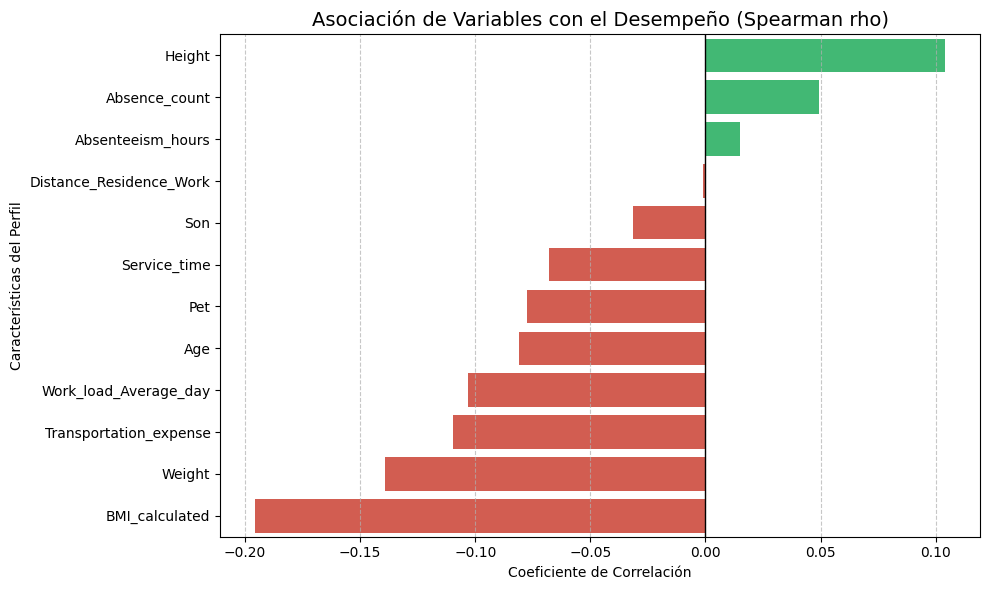

In [75]:
# 1. Creamos un Series con los datos que has obtenido
correlaciones_target = pd.Series({
    'Height': 0.104287,
    'Absence_count': 0.049381,
    'Absenteeism_hours': 0.015056,
    'Distance_Residence_Work': -0.001216,
    'Son': -0.031321,
    'Service_time': -0.067977,
    'Pet': -0.077616,
    'Age': -0.080973,
    'Work_load_Average_day': -0.103270,
    'Transportation_expense': -0.109586,
    'Weight': -0.139090,
    'BMI_calculated': -0.195817
}).sort_values(ascending=False)

# 2. Configuración de la visualización
plt.figure(figsize=(10, 6), facecolor='none')

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in correlaciones_target.values]

ax= sns.barplot(x=correlaciones_target.values, y=correlaciones_target.index, palette=colors)

ax.set_facecolor('none')

# 3. Estética y etiquetas
plt.title('Asociación de Variables con el Desempeño (Spearman rho)', fontsize=14)
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Características del Perfil')
plt.axvline(0, color='black', linestyle='-', linewidth=1) # Línea central
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

pet, son deberiamos segmentarlos en si y no